# Shor's Algorithm for RSA Decryption

The problem of factoring a large semiprime number $N$, which is crucial for cracking the RSA cryptosystem, can be reduced to finding the period $r$ of some function $a^x \pmod N$ where $\text{gcd}(a, N) = 1$. This is because $a^r \equiv 1 \pmod N$, meaning $N$ divides $(a^r - 1)$. If we choose an appropriate $a$ such that $r$ is even, this means that $N$ divides $(a^{r/2}+1)(a^{r/2}-1)$. With the additional constraint that $a^{r/2} \not\equiv -1 \pmod N$, this thus guarantees that $\text{gcd}(a^{r/2}-1, N)$ and $\text{gcd}(a^{r/2}+1, N)$ give nontrivial factors of $N$. Thus, the primary difficulty in classical algorithms cracking RSA comes from the difficulty of finding the period of this function. 

Shor's algorithm achieves exponential speedup over the best known classical algorithm on this period-finding step by recognizing that it can be cast as a quantum phase estimation problem. The operator $U$ performing modular multiplication as $U|y\rangle=|ay\pmod N\rangle$ has eigenvalues $e^{2\pi i s/r}$, meaning quantum phase estimation recovers $s/r$ for some $s$. Subsequently, $r$ is recovered using continued fractions.

Classically, the best known algorithm is sub-exponential as $\mathcal{O}\left(\exp\left(c \cdot (\ln N)^{1/3} (\ln \ln N)^{2/3}\right)\right)$, which is intractable for large $N$, usually $2048$-bit length. By contrast, Shor's reduces to about $\mathcal{O}(n^3)$ where $n = \log_2 N$ is the bitlength of $N$. 

In this notebook I first develop Shor's algorithm adjusting code from my Quantum Phase Estimation notebook. As shown from there, I can recover all the eigenphases of the unitary by using a superposition of the eigenstates, recovering one at random on each run. A convenient choice is simply $|1\rangle$ which is an equal superposition of all $r$ eigenstates. Then I develop the code to crack RSA. Because I am simulating on a classical computer, I test the algorithm with $N = 15$. I also chose not to implement the proper modular exponentiation structure here, instead using unitaries defined as $2^n \times 2^n$ matrices for Shor's structure (for $N = 15$, this is $16 \times 16$). As such, this doesn't truly demonstrate Shor's efficiency, and instead I should implement the better modular exponentiation structure in the future, though even then the efficiency could only be seen on real quantum hardware.

In [50]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import QFTGate, UnitaryGate
from IPython.display import display
import numpy as np
import random
from math import gcd
from fractions import Fraction

In [51]:
#from quantum_phase_estimation notebook with generic unitaries list
def make_qpe_circuit(unitaries, eigenstate, n):
    assert callable(eigenstate)
    eigenstate_size = unitaries[0].num_qubits - unitaries[0].num_ctrl_qubits
    qc = QuantumCircuit(n + eigenstate_size, n)
    eigenstate_qubits = list(range(n, n+eigenstate_size))
    eigenstate(qc, eigenstate_qubits)
    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.append(unitaries[i], [i] + eigenstate_qubits)
    qc.append(QFTGate(n).inverse(), range(n))
    qc.measure(range(n), range(n))
    return qc

In [52]:
def controlled_permutation_unitary(c, N, eigenstate_size):
    dim = 2 ** eigenstate_size
    M = np.zeros((dim, dim)) #2^n x 2^n matrix
    for y in range(dim):
        target = (c * y) % N if y < N else y #permutation matrix sends y to c*y mod N for y<N, y>=N are leftovers in 2^n state space -- dont move
        M[target, y] = 1.0 #[row, column]
    return UnitaryGate(M, f'x{c}').control(1)

In [53]:
def make_shor_unitaries(a, N, n): #n is counting register size, correctly 2 * N.bit_length() - only diff for testing
    eigenstate_size = N.bit_length()
    unitaries = [controlled_permutation_unitary(pow(a, 2**i, N), N, eigenstate_size) for i in range(n)]
    return unitaries

In [54]:
def get_period(qc, a, N, n, shots): #assuming qc is a well constructed shor circuit
    sampler = StatevectorSampler(default_shots=shots)
    result = sampler.run([qc]).result()
    counts = result[0].data.c.get_counts()
    candidates = []
    for outcome, freq in counts.items():
        c = int(outcome, 2) #number corresponding to measured bitstring
        r = Fraction(c, 2**n).limit_denominator(N).denominator #continued fractions gets the s/r that c/2^n approximates
        if r > 1 and pow(a, r, N) == 1:
            candidates.append(r)
    if not candidates: #algorithm didn't find period
        return None
    return candidates[0]

In [55]:
def run_shor_circuit(a, N, n = None, shots = 1000):
    if n is None:
        n = 2 * N.bit_length()
    shor_gates = make_shor_unitaries(a, N, n)
    eigenstate = lambda qc, eigenstate_qubits: qc.x(eigenstate_qubits[0])
    qc = make_qpe_circuit(shor_gates, eigenstate, n)
    display(qc.draw('mpl'))
    r = get_period(qc, a, N, n, shots)
    return r

In [56]:
def get_factors(a, N, r): 
    if r % 2 != 0 or pow(a, r//2, N) == N - 1: #modular pow
        return None
    return gcd(a ** (r//2) - 1, N), gcd(a ** (r//2) + 1, N) #without mod, gcd needs actual int value

In [57]:
def factor_N(N): #N is a semiprime number
    factors = None
    while factors is None:
        a = random.randint(2, N-1)
        print(f'a: {a}')
        if gcd(a, N) != 1: #lucky - a shares factor w/ N, classical; unlikely w/ large N
            g = gcd(a, N)
            factors = g, N // g
        else:
            r = run_shor_circuit(a, N)
            if r is None:
                continue
            factors = get_factors(a, N, r)
    print(f'Factors of {N}: {factors}')
    return factors


In [58]:
#Extended Euclid's Algorithm
def e_gcd(x,y):
    if y == 0:
        return (x, 1, 0)
    else:
        d, a, b = e_gcd(y, x % y)
        return d, b, a - (x//y)*b
    
def get_inverse(mod, n):
    d, A, B = e_gcd(mod, n)
    assert d == 1
    return B % mod

In [59]:
def crack_rsa(c, N, e): #eve intercepts alice's message c in cyphertext and has bob's public key (N, e), but not his private key d
    p, q = factor_N(N)
    phi = (p-1) * (q-1)
    d = get_inverse(phi, e)
    m = pow(c, d, N)
    return m

In [60]:
N, e = 15, 3 #Bob's public key; e chosen to be coprime to (p-1)(q-1)
m = random.randint(0, N - 1) #Alice's message in plaintext
c = pow(m, e, N) #message in cyphertext

a: 7


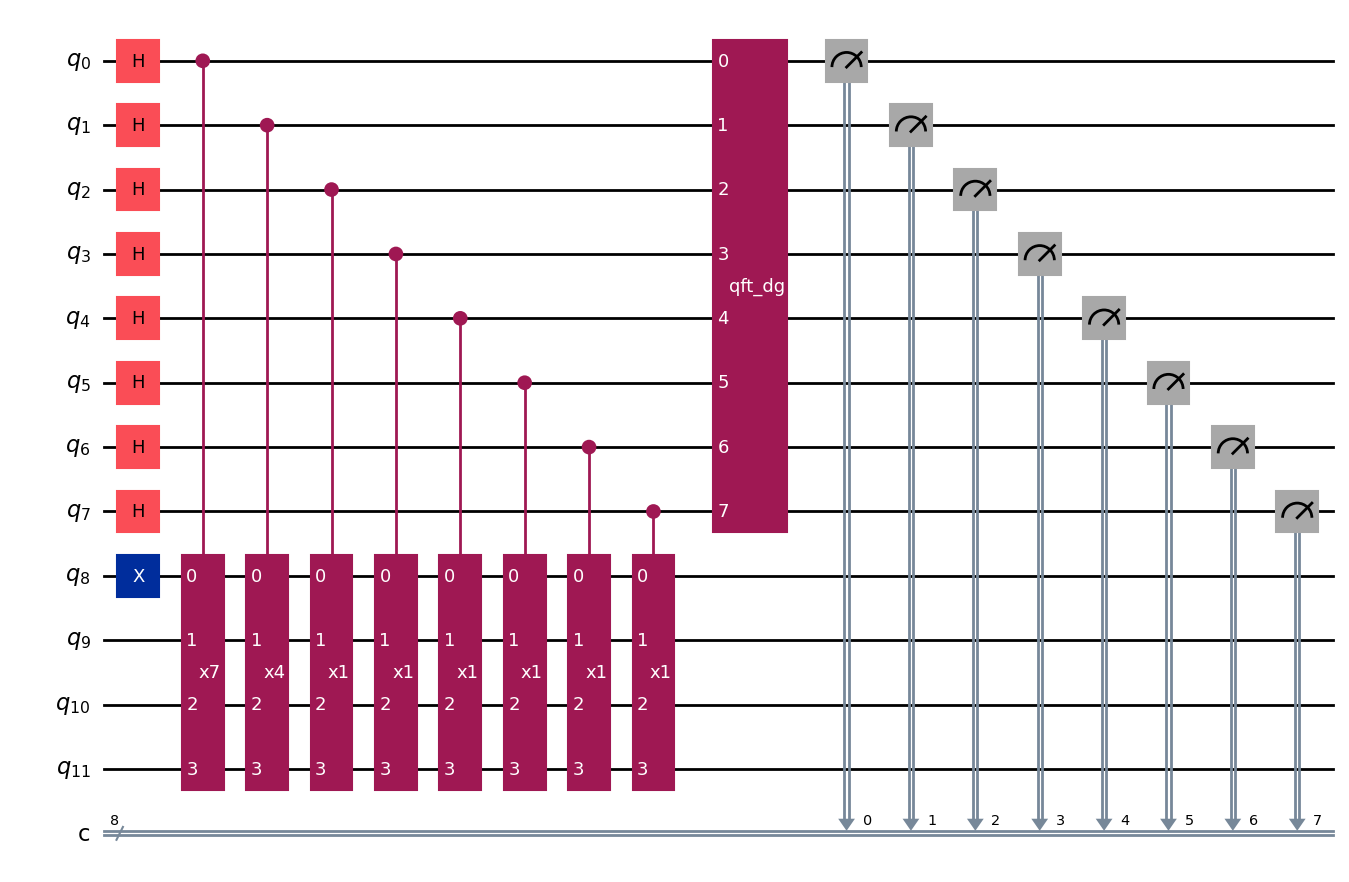

Factors of 15: (3, 5)
Message Successfully Intercepted: 5


In [61]:
message = crack_rsa(c, N, e) #message intercepted by Eve
if message == m:
    print(f'Message Successfully Intercepted: {message}')
else:
    print("Message Not Successfully Intercepted: Got {message}, expected {m}")